# EDA dan Preprocessing - Sentiment Analysis

**Dataset:** Sentiment140 (training.1600000.processed.noemoticon.csv)

**Target:** Klasifikasi sentimen Twitter (Positif / Negatif)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Load Dataset

In [2]:
cols = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv('training.1600000.processed.noemoticon.csv',
                 encoding='latin-1', names=cols)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1600000, 6)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 2. Exploratory Data Analysis (EDA)

In [3]:
# Basic Info
print('Dataset Info:')
print(df.info())

print('\nMissing values:')
print(df.isnull().sum())

Dataset Info:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   ids     1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB
None

Missing values:


target    0
ids       0
date      0
flag      0
user      0
text      0
dtype: int64


Sentiment Distribution (0=Negatif, 4=Positif):
target
0    800000
4    800000
Name: count, dtype: int64


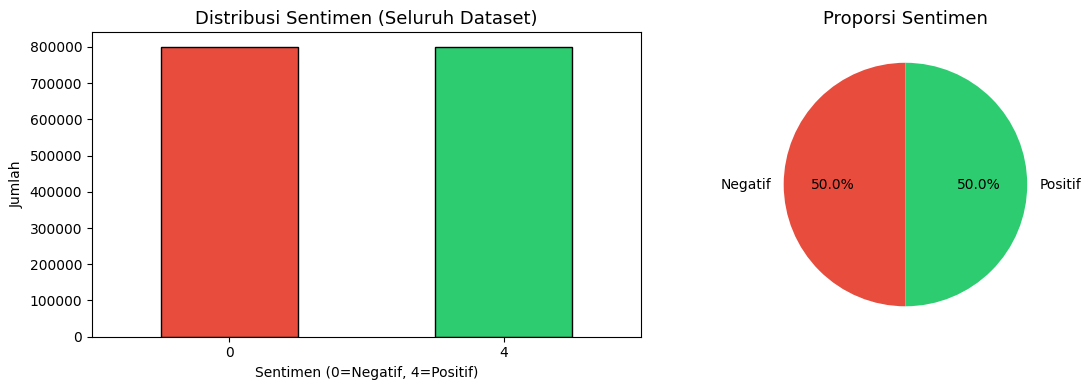

Plot saved as sentiment_distribution.png


In [4]:
# Sentiment Distribution
print('Sentiment Distribution (0=Negatif, 4=Positif):')
print(df['target'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df['target'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Sentimen (Seluruh Dataset)', fontsize=13)
axes[0].set_xlabel('Sentimen (0=Negatif, 4=Positif)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(rotation=0)

# Pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Negatif', 'Positif'], colors=['#e74c3c', '#2ecc71'],
    autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Sentimen', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as sentiment_distribution.png')

Statistik Panjang Teks (kata):
count    1.600000e+06
mean     1.317615e+01
std      6.957978e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.200000e+01
75%      1.900000e+01
max      6.400000e+01
Name: text_length, dtype: float64


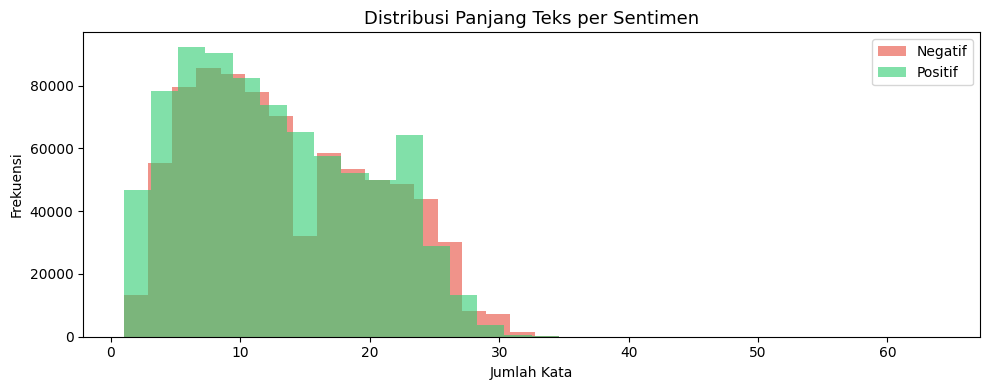

In [5]:
# Text Length Analysis
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
print('Statistik Panjang Teks (kata):')
print(df['text_length'].describe())

plt.figure(figsize=(10, 4))
for val, label, color in [(0, 'Negatif', '#e74c3c'), (4, 'Positif', '#2ecc71')]:
    subset = df[df['target']==val]['text_length']
    plt.hist(subset, bins=30, alpha=0.6, label=label, color=color)
plt.title('Distribusi Panjang Teks per Sentimen', fontsize=13)
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sampling Dataset

Dataset terlalu besar (1.6 juta baris). Kita sample **10.000 baris** secara stratified (5000 negatif + 5000 positif) untuk proses training yang efisien.

In [6]:
SAMPLE_SIZE = 5000

df_neg = df[df['target'] == 0].sample(n=SAMPLE_SIZE, random_state=42)
df_pos = df[df['target'] == 4].sample(n=SAMPLE_SIZE, random_state=42)
df_sample = pd.concat([df_neg, df_pos]).reset_index(drop=True)

print('Sample shape:', df_sample.shape)
print(df_sample['target'].value_counts())

Sample shape: (10000, 7)
target
0    5000
4    5000
Name: count, dtype: int64


## 4. Text Preprocessing

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.strip()
    return text

# Map target ke binary
df_sample['sentiment'] = df_sample['target'].map({0: 0, 4: 1})

# Apply cleaning
df_sample['clean_text'] = df_sample['text'].apply(clean_text)

# Drop empty rows
df_sample = df_sample[df_sample['clean_text'] != '']

print('Shape setelah preprocessing:', df_sample.shape)

# Contoh hasil preprocessing
pd.set_option('display.max_colwidth', 80)
df_sample[['text', 'clean_text', 'sentiment']].head(10)

Shape setelah preprocessing: (9981, 9)


,text,clean_text,sentiment
0,@xnausikaax oh no! where did u order from? that's horrible,oh no where did u order from thats horrible,0
1,A great hard training weekend is over. a couple days of rest and lets do it...,a great hard training weekend is over a couple days of rest and lets do it ...,0
2,"Right, off to work Only 5 hours to go until I'm free xD",right off to work only hours to go until im free xd,0
3,I am craving for japanese food,i am craving for japanese food,0
4,Jean Michel Jarre concert tomorrow gotta work 7-3 before though,jean michel jarre concert tomorrow gotta work before though,0
5,@xPowxBangxBoomx dammiitt!! i wish i had MTV,dammiitt i wish i had mtv,0
6,@Rohan_01 You know..it's really sad that u know that ur classmate don't care...,you knowits really sad that u know that ur classmate dont care about you ...,0
7,@FaketragedyCom i know,i know,0
8,@JudahGabriel i wish i had that much to say,i wish i had that much to say,0
9,"ow, i can't move my neck or my back hurts too much and i don't know why D:",ow i cant move my neck or my back hurts too much and i dont know why d,0


## 5. Simpan Dataset yang Sudah Bersih

In [8]:
final_df = df_sample[['clean_text', 'sentiment']]
final_df.to_csv('cleaned_sample.csv', index=False)
print('Dataset berhasil disimpan ke cleaned_sample.csv')
print('Shape:', final_df.shape)
final_df.head()

Dataset berhasil disimpan ke cleaned_sample.csv
Shape: (9981, 2)


,clean_text,sentiment
0,oh no where did u order from thats horrible,0
1,a great hard training weekend is over a couple days of rest and lets do it ...,0
2,right off to work only hours to go until im free xd,0
3,i am craving for japanese food,0
4,jean michel jarre concert tomorrow gotta work before though,0
